# Biohub – Cell Tracking During Development

## Chapter 27: Link Detections Across Consecutive Timepoints

**Objective:** Build and validate the first temporal-linking algorithm.

This chapter begins with **ground-truth nodes** so detection errors do not contaminate the linking experiment. After validating the linker against true GEFF graph edges, the same logic is prepared for Chapter 26 detections.

### Main workflow

1. Load image, GT nodes, and graph edges  
2. Select consecutive timepoints  
3. Compute 3D movement distances  
4. Build nearest-neighbor links  
5. Enforce a maximum movement radius  
6. Compare predicted links with true GEFF edges  
7. Test greedy one-to-one matching  
8. Evaluate several frame pairs  
9. Prepare predicted detections for linking


# 🎯 Learning Objectives

By the end of this notebook, I will be able to:

- load GEFF nodes and edges
- identify true consecutive-frame edges
- compute pairwise 3D distances
- construct nearest-neighbor links
- enforce a maximum movement threshold
- calculate link precision and recall
- diagnose duplicate target assignments
- compare nearest-neighbor and greedy one-to-one linking
- apply the linker to ranked model detections


# 🧠 Why validate linking with GT first?

A tracking system can fail because of:

- **detection errors**: missing, duplicated, or false cells
- **linking errors**: connecting the wrong cells across time

Testing the linker on GT nodes isolates the temporal-association problem. If linking works on GT but later fails on predictions, detector noise is the likely cause.


# Step 1 — Install and Import Packages


In [1]:

!pip install -q zarr

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from scipy.spatial.distance import cdist
from IPython.display import display

print("Imports successful.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 70.0 MB/s eta 0:00:00
Imports successful.


# Step 2 — Load the Competition Sample


In [2]:

base = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
sample_id = "44b6_12dfb391"

train_path = base / "train"
zarr_path = train_path / f"{sample_id}.zarr"
geff_path = train_path / f"{sample_id}.geff"

print("Competition path exists:", base.exists())
print("Image path exists:", zarr_path.exists())
print("GEFF path exists:", geff_path.exists())

if not base.exists():
    raise FileNotFoundError(
        "Attach 'Biohub Cell Tracking During Development' with Kaggle Add Input."
    )

image_root = zarr.open(zarr_path, mode="r")
image = image_root["0"]

geff = zarr.open(geff_path, mode="r")

nodes_df = pd.DataFrame({
    "node_id": geff["nodes/ids"][:],
    "t": geff["nodes/props/t/values"][:],
    "z": geff["nodes/props/z/values"][:],
    "y": geff["nodes/props/y/values"][:],
    "x": geff["nodes/props/x/values"][:],
})

print("Image shape:", image.shape)
print("GT nodes:", len(nodes_df))
display(nodes_df.head())


Competition path exists: True
Image path exists: True
GEFF path exists: True
Image shape: (100, 64, 256, 256)
GT nodes: 788


,node_id,t,z,y,x
0,106000000037,0,35,61,189
1,106000000040,0,15,194,55
2,106000000041,0,7,239,56
3,106000000043,0,27,211,109
4,106000000056,0,40,127,130


# Step 3 — Inspect the GEFF Tree

This helps locate the edge arrays if their internal names differ.


In [3]:

def print_zarr_tree(group, prefix="", depth=0, max_depth=4):
    if depth > max_depth:
        return

    try:
        keys = list(group.keys())
    except Exception:
        return

    for key in keys:
        obj = group[key]
        print(f"{prefix}{key}")
        if hasattr(obj, "keys"):
            print_zarr_tree(
                obj,
                prefix=prefix + "  ",
                depth=depth + 1,
                max_depth=max_depth,
            )

print_zarr_tree(geff)


nodes
  ids
  props
    y
      values
    t
      values
    z
      values
    x
      values
edges
  ids
  props


# Step 4 — Load GT Edges Robustly


In [4]:

def first_existing_array(group, paths):
    for path in paths:
        try:
            return np.asarray(group[path][:]), path
        except Exception:
            pass
    return None, None


def load_geff_edges(geff_group):
    source_paths = [
        "edges/source",
        "edges/sources",
        "edges/source_ids",
        "edges/props/source/values",
        "edges/props/source_id/values",
    ]

    target_paths = [
        "edges/target",
        "edges/targets",
        "edges/target_ids",
        "edges/props/target/values",
        "edges/props/target_id/values",
    ]

    sources, source_path = first_existing_array(
        geff_group, source_paths
    )
    targets, target_path = first_existing_array(
        geff_group, target_paths
    )

    if sources is not None and targets is not None:
        print("Source path:", source_path)
        print("Target path:", target_path)
        return pd.DataFrame({
            "source": sources,
            "target": targets,
        })

    for path in [
        "edges/ids",
        "edges/index",
        "edges/indices",
        "edges/endpoints",
    ]:
        try:
            arr = np.asarray(geff_group[path][:])

            if arr.ndim == 2 and arr.shape[1] == 2:
                print("Edge-pair path:", path)
                return pd.DataFrame(
                    arr, columns=["source", "target"]
                )

            if arr.ndim == 2 and arr.shape[0] == 2:
                print("Transposed edge-pair path:", path)
                return pd.DataFrame({
                    "source": arr[0],
                    "target": arr[1],
                })
        except Exception:
            pass

    raise KeyError(
        "Could not identify edge arrays automatically. "
        "Use the printed Zarr tree to update load_geff_edges()."
    )


edges_df = load_geff_edges(geff)

print("GT edges:", len(edges_df))
display(edges_df.head())


Edge-pair path: edges/ids
GT edges: 773


,source,target
0,106000000037,107000000037
1,106000000040,107000000040
2,106000000041,107000000041
3,106000000043,107000000043
4,106000000056,107000000056


# Step 5 — Add Node Times and Coordinates to Every Edge


In [5]:

source_nodes = nodes_df.rename(columns={
    "node_id": "source",
    "t": "source_t",
    "z": "source_z",
    "y": "source_y",
    "x": "source_x",
})

target_nodes = nodes_df.rename(columns={
    "node_id": "target",
    "t": "target_t",
    "z": "target_z",
    "y": "target_y",
    "x": "target_x",
})

edge_detail_df = (
    edges_df
    .merge(source_nodes, on="source", how="left")
    .merge(target_nodes, on="target", how="left")
)

edge_detail_df["time_gap"] = (
    edge_detail_df["target_t"] -
    edge_detail_df["source_t"]
)

edge_detail_df["movement_dist"] = np.sqrt(
    (edge_detail_df["target_z"] - edge_detail_df["source_z"]) ** 2 +
    (edge_detail_df["target_y"] - edge_detail_df["source_y"]) ** 2 +
    (edge_detail_df["target_x"] - edge_detail_df["source_x"]) ** 2
)

display(edge_detail_df.head())
print(edge_detail_df["time_gap"].value_counts().sort_index())


,source,target,source_t,source_z,source_y,source_x,target_t,target_z,target_y,target_x,time_gap,movement_dist
0,106000000037,107000000037,0,35,61,189,1,35,60,188,1,1.414214
1,106000000040,107000000040,0,15,194,55,1,16,196,58,1,3.741657
2,106000000041,107000000041,0,7,239,56,1,7,238,55,1,1.414214
3,106000000043,107000000043,0,27,211,109,1,27,212,108,1,1.414214
4,106000000056,107000000056,0,40,127,130,1,41,125,126,1,4.582576


time_gap
1    773
Name: count, dtype: int64


# Step 6 — Examine True Consecutive Movement Distances


In [6]:

consecutive_edges_df = (
    edge_detail_df[edge_detail_df["time_gap"] == 1]
    .copy()
    .reset_index(drop=True)
)

print("Consecutive GT edges:", len(consecutive_edges_df))
display(consecutive_edges_df["movement_dist"].describe())


Consecutive GT edges: 773


count    773.000000
mean       2.296502
std        1.390316
min        0.000000
25%        1.414214
50%        2.236068
75%        3.000000
max       12.000000
Name: movement_dist, dtype: float64

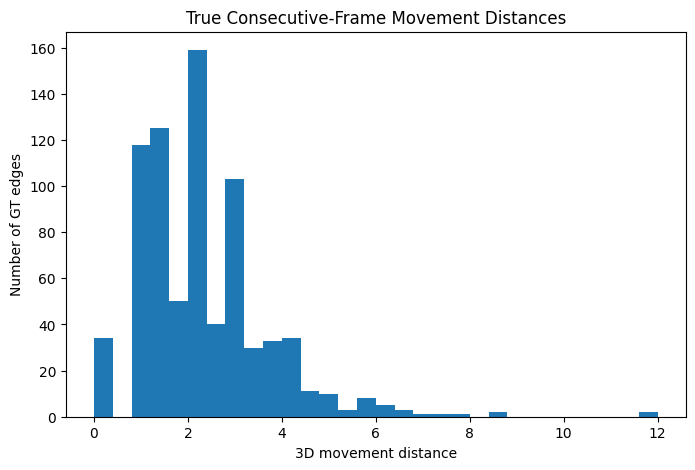

In [7]:

plt.figure(figsize=(8, 5))
plt.hist(
    consecutive_edges_df["movement_dist"],
    bins=30,
)
plt.title("True Consecutive-Frame Movement Distances")
plt.xlabel("3D movement distance")
plt.ylabel("Number of GT edges")
plt.show()


# Step 7 — Select a Consecutive Frame Pair


In [8]:

source_t = 60
target_t = source_t + 1

source_gt_df = (
    nodes_df[nodes_df["t"] == source_t]
    .copy()
    .reset_index(drop=True)
)

target_gt_df = (
    nodes_df[nodes_df["t"] == target_t]
    .copy()
    .reset_index(drop=True)
)

true_pair_edges_df = (
    consecutive_edges_df[
        (consecutive_edges_df["source_t"] == source_t) &
        (consecutive_edges_df["target_t"] == target_t)
    ]
    .copy()
    .reset_index(drop=True)
)

print("Source nodes:", len(source_gt_df))
print("Target nodes:", len(target_gt_df))
print("True edges:", len(true_pair_edges_df))

display(
    true_pair_edges_df[
        ["source", "target", "movement_dist"]
    ].head()
)


Source nodes: 9
Target nodes: 9
True edges: 9


,source,target,movement_dist
0,166000000039,167000000039,2.449490
1,166000000042,167000000042,3.605551
2,166000000043,167000000043,2.236068
3,166000000044,167000000044,2.236068
4,166000000045,167000000045,2.236068


# Step 8 — Pairwise Distance Matrix


In [9]:

source_points = source_gt_df[
    ["z", "y", "x"]
].to_numpy(dtype=float)

target_points = target_gt_df[
    ["z", "y", "x"]
].to_numpy(dtype=float)

pair_distance_matrix = cdist(
    source_points,
    target_points,
)

print("Distance matrix shape:", pair_distance_matrix.shape)

if pair_distance_matrix.size:
    display(
        pd.DataFrame(pair_distance_matrix)
        .iloc[:5, :5]
    )


Distance matrix shape: (9, 9)


,0,1,2,3,4
0,2.449490,221.214828,265.431724,187.557991,203.990196
1,216.893983,3.605551,49.588305,46.314145,50.129831
2,263.098841,45.000000,2.236068,92.059763,72.532751
3,188.814724,49.406477,92.752358,2.236068,75.769387
4,201.675482,52.962251,76.635501,75.319320,2.236068


# Step 9 — Nearest-Neighbor Linker


In [10]:

def link_nearest_neighbors(
    source_df,
    target_df,
    max_movement=np.inf,
):
    required = {"node_id", "z", "y", "x"}

    if not required.issubset(source_df.columns):
        raise KeyError(
            f"source_df missing: {required - set(source_df.columns)}"
        )

    if not required.issubset(target_df.columns):
        raise KeyError(
            f"target_df missing: {required - set(target_df.columns)}"
        )

    if len(source_df) == 0 or len(target_df) == 0:
        return pd.DataFrame(
            columns=["source", "target", "distance", "accepted"]
        )

    source_points = source_df[
        ["z", "y", "x"]
    ].to_numpy(dtype=float)

    target_points = target_df[
        ["z", "y", "x"]
    ].to_numpy(dtype=float)

    dist = cdist(source_points, target_points)

    nearest_target_idx = dist.argmin(axis=1)
    nearest_dist = dist[
        np.arange(len(source_df)),
        nearest_target_idx,
    ]

    result = pd.DataFrame({
        "source": source_df["node_id"].to_numpy(),
        "target": target_df.iloc[
            nearest_target_idx
        ]["node_id"].to_numpy(),
        "distance": nearest_dist,
    })

    result["accepted"] = (
        result["distance"] <= max_movement
    )

    return result


initial_max_movement = 10.0

nn_links_df = link_nearest_neighbors(
    source_gt_df,
    target_gt_df,
    max_movement=initial_max_movement,
)

display(nn_links_df)


,source,target,distance,accepted
0,166000000039,167000000039,2.449490,True
1,166000000042,167000000042,3.605551,True
2,166000000043,167000000043,2.236068,True
3,166000000044,167000000044,2.236068,True
4,166000000045,167000000045,2.236068,True
5,166000000053,167000000053,1.414214,True
6,166000000072,167000000072,3.605551,True
7,166000000073,167000000073,2.236068,True
8,166000000075,167000000075,1.414214,True


# Step 10 — Link Evaluation


In [11]:

def evaluate_links(
    predicted_links_df,
    true_edges_df,
):
    predicted = predicted_links_df.copy()

    if "accepted" in predicted.columns:
        predicted = predicted[
            predicted["accepted"]
        ].copy()

    pred_pairs = set(
        map(
            tuple,
            predicted[["source", "target"]].to_numpy(),
        )
    )

    true_pairs = set(
        map(
            tuple,
            true_edges_df[["source", "target"]].to_numpy(),
        )
    )

    correct_pairs = pred_pairs & true_pairs
    false_pairs = pred_pairs - true_pairs
    missed_pairs = true_pairs - pred_pairs

    return {
        "num_predicted_links": len(pred_pairs),
        "num_true_links": len(true_pairs),
        "num_correct_links": len(correct_pairs),
        "num_false_links": len(false_pairs),
        "num_missed_links": len(missed_pairs),
        "link_precision": (
            len(correct_pairs) / len(pred_pairs)
            if pred_pairs else np.nan
        ),
        "link_recall": (
            len(correct_pairs) / len(true_pairs)
            if true_pairs else np.nan
        ),
        "correct_pairs": correct_pairs,
        "false_pairs": false_pairs,
        "missed_pairs": missed_pairs,
    }


nn_eval = evaluate_links(
    nn_links_df,
    true_pair_edges_df,
)

pd.Series({
    key: value
    for key, value in nn_eval.items()
    if not isinstance(value, set)
})


num_predicted_links    9.0
num_true_links         9.0
num_correct_links      9.0
num_false_links        0.0
num_missed_links       0.0
link_precision         1.0
link_recall            1.0
dtype: float64

# Step 11 — Diagnose Duplicate Target Assignments


In [12]:

accepted_nn_links_df = nn_links_df[
    nn_links_df["accepted"]
].copy()

target_assignment_counts = (
    accepted_nn_links_df["target"]
    .value_counts()
    .rename_axis("target")
    .reset_index(name="num_sources")
)

duplicate_targets_df = target_assignment_counts[
    target_assignment_counts["num_sources"] > 1
]

print("Duplicate target assignments:", len(duplicate_targets_df))
display(duplicate_targets_df)


Duplicate target assignments: 0


,target,num_sources


# Step 12 — Greedy One-to-One Linker


In [13]:

def link_greedy_one_to_one(
    source_df,
    target_df,
    max_movement=np.inf,
):
    if len(source_df) == 0 or len(target_df) == 0:
        return pd.DataFrame(
            columns=["source", "target", "distance"]
        )

    source_points = source_df[
        ["z", "y", "x"]
    ].to_numpy(dtype=float)

    target_points = target_df[
        ["z", "y", "x"]
    ].to_numpy(dtype=float)

    dist = cdist(source_points, target_points)

    source_idx, target_idx = np.indices(dist.shape)

    pair_df = pd.DataFrame({
        "source_index": source_idx.ravel(),
        "target_index": target_idx.ravel(),
        "distance": dist.ravel(),
    })

    pair_df = (
        pair_df[pair_df["distance"] <= max_movement]
        .sort_values("distance")
        .reset_index(drop=True)
    )

    used_sources = set()
    used_targets = set()
    accepted_rows = []

    for _, row in pair_df.iterrows():
        s_idx = int(row["source_index"])
        t_idx = int(row["target_index"])

        if s_idx in used_sources or t_idx in used_targets:
            continue

        used_sources.add(s_idx)
        used_targets.add(t_idx)

        accepted_rows.append({
            "source": source_df.iloc[s_idx]["node_id"],
            "target": target_df.iloc[t_idx]["node_id"],
            "distance": float(row["distance"]),
        })

    return pd.DataFrame(accepted_rows)


greedy_links_df = link_greedy_one_to_one(
    source_gt_df,
    target_gt_df,
    max_movement=initial_max_movement,
)

greedy_eval = evaluate_links(
    greedy_links_df,
    true_pair_edges_df,
)

display(greedy_links_df)

pd.Series({
    key: value
    for key, value in greedy_eval.items()
    if not isinstance(value, set)
})


,source,target,distance
0,1.660000e+11,1.670000e+11,1.414214
1,1.660000e+11,1.670000e+11,1.414214
2,1.660000e+11,1.670000e+11,2.236068
3,1.660000e+11,1.670000e+11,2.236068
4,1.660000e+11,1.670000e+11,2.236068
5,1.660000e+11,1.670000e+11,2.236068
6,1.660000e+11,1.670000e+11,2.449490
7,1.660000e+11,1.670000e+11,3.605551
8,1.660000e+11,1.670000e+11,3.605551


num_predicted_links    9.0
num_true_links         9.0
num_correct_links      9.0
num_false_links        0.0
num_missed_links       0.0
link_precision         1.0
link_recall            1.0
dtype: float64

# Step 13 — Compare Movement Radii


In [14]:

radius_values = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]

radius_rows = []

for radius in radius_values:
    for method_name, linker in [
        ("nearest_neighbor", link_nearest_neighbors),
        ("greedy_one_to_one", link_greedy_one_to_one),
    ]:
        links = linker(
            source_gt_df,
            target_gt_df,
            max_movement=radius,
        )

        result = evaluate_links(
            links,
            true_pair_edges_df,
        )

        radius_rows.append({
            "method": method_name,
            "max_movement": radius,
            "num_predicted_links": result["num_predicted_links"],
            "num_correct_links": result["num_correct_links"],
            "link_precision": result["link_precision"],
            "link_recall": result["link_recall"],
        })

radius_results_df = pd.DataFrame(radius_rows)
radius_results_df


,method,max_movement,num_predicted_links,num_correct_links,link_precision,link_recall
0,nearest_neighbor,2,2,2,1.0,0.222222
1,greedy_one_to_one,2,2,2,1.0,0.222222
2,nearest_neighbor,3,7,7,1.0,0.777778
3,greedy_one_to_one,3,7,7,1.0,0.777778
4,nearest_neighbor,4,9,9,1.0,1.000000
5,greedy_one_to_one,4,9,9,1.0,1.000000
6,nearest_neighbor,5,9,9,1.0,1.000000
7,greedy_one_to_one,5,9,9,1.0,1.000000
8,nearest_neighbor,6,9,9,1.0,1.000000
9,greedy_one_to_one,6,9,9,1.0,1.000000


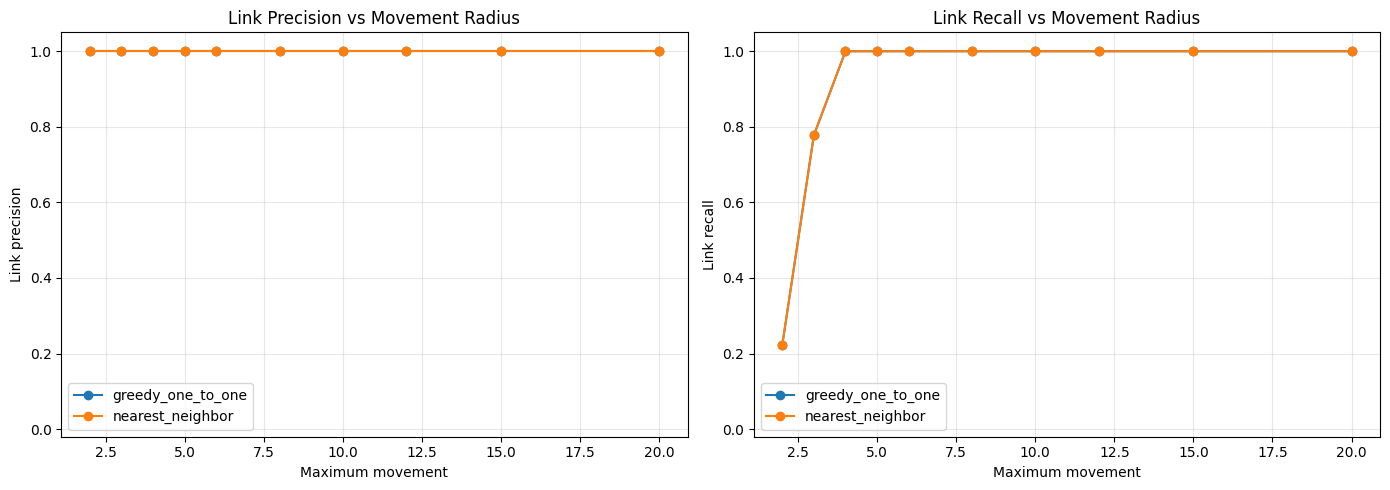

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for method_name, group in radius_results_df.groupby("method"):
    group = group.sort_values("max_movement")

    axes[0].plot(
        group["max_movement"],
        group["link_precision"],
        marker="o",
        label=method_name,
    )

    axes[1].plot(
        group["max_movement"],
        group["link_recall"],
        marker="o",
        label=method_name,
    )

axes[0].set_title("Link Precision vs Movement Radius")
axes[0].set_xlabel("Maximum movement")
axes[0].set_ylabel("Link precision")
axes[0].set_ylim(-0.02, 1.05)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Link Recall vs Movement Radius")
axes[1].set_xlabel("Maximum movement")
axes[1].set_ylabel("Link recall")
axes[1].set_ylim(-0.02, 1.05)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


# Step 14 — Evaluate Several Consecutive GT Frame Pairs


In [16]:

frame_pairs = [
    (0, 1),
    (7, 8),
    (8, 9),
    (19, 20),
    (39, 40),
    (59, 60),
    (60, 61),
    (79, 80),
    (80, 81),
]

chosen_radius = 10.0
multi_pair_rows = []

for t0, t1 in frame_pairs:
    source_df = (
        nodes_df[nodes_df["t"] == t0]
        .copy()
        .reset_index(drop=True)
    )

    target_df = (
        nodes_df[nodes_df["t"] == t1]
        .copy()
        .reset_index(drop=True)
    )

    true_edges_t = consecutive_edges_df[
        (consecutive_edges_df["source_t"] == t0) &
        (consecutive_edges_df["target_t"] == t1)
    ].copy()

    for method_name, linker in [
        ("nearest_neighbor", link_nearest_neighbors),
        ("greedy_one_to_one", link_greedy_one_to_one),
    ]:
        predicted_links = linker(
            source_df,
            target_df,
            max_movement=chosen_radius,
        )

        result = evaluate_links(
            predicted_links,
            true_edges_t,
        )

        multi_pair_rows.append({
            "source_t": t0,
            "target_t": t1,
            "method": method_name,
            "num_source_nodes": len(source_df),
            "num_target_nodes": len(target_df),
            "num_true_links": result["num_true_links"],
            "num_predicted_links": result["num_predicted_links"],
            "num_correct_links": result["num_correct_links"],
            "link_precision": result["link_precision"],
            "link_recall": result["link_recall"],
        })

multi_pair_results_df = pd.DataFrame(multi_pair_rows)
multi_pair_results_df


,source_t,target_t,method,num_source_nodes,num_target_nodes,num_true_links,num_predicted_links,num_correct_links,link_precision,link_recall
0,0,1,nearest_neighbor,10,10,10,10,10,1.0,1.0
1,0,1,greedy_one_to_one,10,10,10,10,10,1.0,1.0
2,7,8,nearest_neighbor,10,11,10,10,10,1.0,1.0
3,7,8,greedy_one_to_one,10,11,10,10,10,1.0,1.0
4,8,9,nearest_neighbor,11,11,11,11,11,1.0,1.0
5,8,9,greedy_one_to_one,11,11,11,11,11,1.0,1.0
6,19,20,nearest_neighbor,9,9,9,9,9,1.0,1.0
7,19,20,greedy_one_to_one,9,9,9,9,9,1.0,1.0
8,39,40,nearest_neighbor,8,9,8,8,8,1.0,1.0
9,39,40,greedy_one_to_one,8,9,8,8,8,1.0,1.0


# Step 15 — Average GT Linking Performance


In [17]:

average_gt_linking_df = (
    multi_pair_results_df
    .groupby("method", as_index=False)
    .agg(
        mean_link_precision=("link_precision", "mean"),
        mean_link_recall=("link_recall", "mean"),
        total_true_links=("num_true_links", "sum"),
        total_correct_links=("num_correct_links", "sum"),
    )
)

average_gt_linking_df


,method,mean_link_precision,mean_link_recall,total_true_links,total_correct_links
0,greedy_one_to_one,1.0,1.0,77,77
1,nearest_neighbor,1.0,1.0,77,77


# Step 16 — Visualize Links in XY Projection


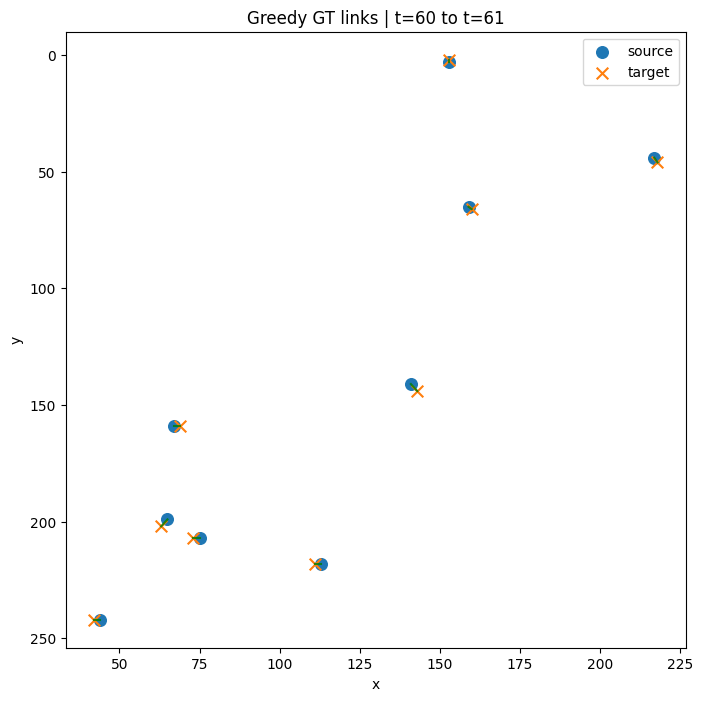

In [18]:

def plot_xy_links(
    source_df,
    target_df,
    predicted_links_df,
    true_edges_df,
    title,
):
    true_pairs = set(
        map(
            tuple,
            true_edges_df[["source", "target"]].to_numpy(),
        )
    )

    source_lookup = source_df.set_index("node_id")
    target_lookup = target_df.set_index("node_id")

    plt.figure(figsize=(8, 8))

    plt.scatter(
        source_df["x"],
        source_df["y"],
        s=70,
        label="source",
    )

    plt.scatter(
        target_df["x"],
        target_df["y"],
        s=70,
        marker="x",
        label="target",
    )

    links = predicted_links_df.copy()

    if "accepted" in links.columns:
        links = links[links["accepted"]]

    for _, row in links.iterrows():
        source_id = row["source"]
        target_id = row["target"]

        if (
            source_id not in source_lookup.index or
            target_id not in target_lookup.index
        ):
            continue

        source_row = source_lookup.loc[source_id]
        target_row = target_lookup.loc[target_id]

        is_correct = (source_id, target_id) in true_pairs

        plt.plot(
            [source_row["x"], target_row["x"]],
            [source_row["y"], target_row["y"]],
            color="green" if is_correct else "red",
            linewidth=1.5,
            alpha=0.8,
        )

    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()


plot_xy_links(
    source_gt_df,
    target_gt_df,
    greedy_links_df,
    true_pair_edges_df,
    title=f"Greedy GT links | t={source_t} to t={target_t}",
)


# Step 17 — Load Chapter 26 Ranked Detections

A new Kaggle notebook session may not contain `/kaggle/working` files from another notebook. Save the Chapter 26 CSV as a Kaggle dataset or regenerate detections in this notebook if needed.


In [19]:

chapter26_csv = Path(
    "/kaggle/working/chapter26_ranked_detections.csv"
)

if chapter26_csv.exists():
    ranked_detections_df = pd.read_csv(chapter26_csv)

    print("Loaded:", chapter26_csv)
    display(ranked_detections_df.head())

else:
    ranked_detections_df = None

    print(
        "Chapter 26 CSV not found in this session. "
        "Run Chapter 26 first or attach its saved output."
    )


Chapter 26 CSV not found in this session. Run Chapter 26 first or attach its saved output.


# Step 18 — Prepare Predicted Detection IDs


In [20]:

def prepare_detection_nodes(
    detections_df,
    t,
    top_k=200,
):
    frame_df = (
        detections_df[detections_df["t"] == t]
        .sort_values("rank_position")
        .head(top_k)
        .copy()
        .reset_index(drop=True)
    )

    frame_df["node_id"] = [
        f"pred_t{t}_{i}"
        for i in range(len(frame_df))
    ]

    return frame_df


# Step 19 — Generic Predicted-Detection Linker

Use this after the detection table contains two consecutive timepoints such as `60` and `61`.


In [21]:

def link_predicted_detections(
    detections_df,
    source_t,
    target_t,
    top_k=200,
    max_movement=10.0,
    method="greedy_one_to_one",
):
    source_df = prepare_detection_nodes(
        detections_df,
        t=source_t,
        top_k=top_k,
    )

    target_df = prepare_detection_nodes(
        detections_df,
        t=target_t,
        top_k=top_k,
    )

    if method == "nearest_neighbor":
        links_df = link_nearest_neighbors(
            source_df,
            target_df,
            max_movement=max_movement,
        )

    elif method == "greedy_one_to_one":
        links_df = link_greedy_one_to_one(
            source_df,
            target_df,
            max_movement=max_movement,
        )

    else:
        raise ValueError(
            "method must be 'nearest_neighbor' or 'greedy_one_to_one'"
        )

    return {
        "source_detections": source_df,
        "target_detections": target_df,
        "links": links_df,
    }


# Example:
#
# predicted_link_output = link_predicted_detections(
#     detections_df=ranked_detections_df,
#     source_t=60,
#     target_t=61,
#     top_k=200,
#     max_movement=chosen_radius,
#     method="greedy_one_to_one",
# )
#
# display(predicted_link_output["links"].head())


# 📝 Lesson Notes

## Nearest-neighbor assumptions

Nearest-neighbor linking works best when:

- cells move only a short distance
- cells are well separated
- detections are accurate
- there are no divisions

## Why greedy one-to-one helps

Independent nearest-neighbor linking can send several sources to the same target. Greedy one-to-one matching removes those duplicates, but it is still locally greedy rather than globally optimal.

## Important limitation

One-to-one matching cannot represent:

```text
one parent → two children
```

Division-aware tracking comes later.


# 📊 Chapter 27 Results

This notebook creates:

- a robust GEFF edge loader
- consecutive GT edge tables
- true movement-distance summaries
- nearest-neighbor linking
- greedy one-to-one linking
- link precision and recall metrics
- movement-radius comparisons
- multi-frame-pair evaluation
- utilities for predicted-detection linking


# Chapter 27 Conclusion Template

## True movement distances
- median movement:
- 90th percentile:
- maximum consecutive movement:

## Nearest neighbor
- selected radius:
- mean precision:
- mean recall:
- duplicate target count:

## Greedy one-to-one
- mean precision:
- mean recall:
- improvement over nearest neighbor:

## Final decision
Simple spatial linking is:

```text
good enough / not good enough
```

for ordinary continuation links.

## Suggested Chapter 28

### Chapter 28 — Build a Global Link Cost Matrix

Next steps:

- combine spatial distance with detection quality
- add appearance-change features
- build a normalized link-cost matrix
- prepare for Hungarian assignment
